In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

In [2]:
sns.set_theme(style="whitegrid", palette="pastel")

In [3]:
mapping = {
    'EDAnonymous': 'eating_disorder',
    'addiction': 'substance_use_disorder',
    'alcoholism': 'alcohol_use_disorder',
    'anxiety': 'generalized_anxiety',
    'autism': 'autism_spectrum',
    'bipolarreddit': 'bipolar_disorder',
    'bpd': 'borderline_personality',
    'depression': 'major_depressive',
    'healthanxiety': 'illness_anxiety',
    'lonely': 'social_isolation',
    'socialanxiety': 'social_anxiety',
    'suicidewatch': 'suicidal_risk',
}

In [4]:
df = pd.read_csv('./archive/train.csv')

In [5]:
df['subreddit'] = df['subreddit'].replace(mapping)

Info:

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 584502 entries, 0 to 584501
Data columns (total 6 columns):
 #   Column       Non-Null Count   Dtype
---  ------       --------------   -----
 0   post         584502 non-null  str  
 1   author       584502 non-null  str  
 2   date         584502 non-null  str  
 3   subreddit    584502 non-null  str  
 4   post_masked  584502 non-null  str  
 5   post_clean   584502 non-null  str  
dtypes: str(6)
memory usage: 1.8 GB


Desc:

In [7]:
df.describe()

,post,author,date,subreddit,post_masked,post_clean
count,584502,584502,584502,584502,584502,584502
unique,584502,493176,476,16,584432,584443
top,"First time teaching class of 9-13 Hello, I'm c...",[deleted],2019/01/03,non-mental,What is the difference between a chickpea and ...,What is the difference between a chickpea and ...
freq,1,18,3052,327696,4,4


Show dataset:

In [8]:
df

,post,author,date,subreddit,post_masked,post_clean
0,"First time teaching class of 9-13 Hello, I'm c...",Nakatsukasa,2019/01/01,non-mental,First time teaching class of [NUM]-[NUM] Hello...,First time teaching class of [NUM]-[NUM] Hello...
1,How do I get my 6th graders to care about poet...,zdnewcomb,2019/01/01,non-mental,How do I get my [NUM]th graders to care about ...,How do I get my [NUM]th graders to care about ...
2,"Am I crazy? (Teaching related, I swear) I just...",PhasmaUrbomach,2019/01/01,non-mental,"Am I crazy? (Teaching related, I swear) I just...","Am I crazy? (Teaching related, I swear) I just..."
3,Starting My 1st Year Next Monday and Need Help...,southernbelleteach,2019/01/01,non-mental,Starting My [NUM]st Year Next Monday and Need ...,Starting My [NUM]st Year Next Monday and Need ...
4,Best way to teach art to children below 10 I'm...,ItsSaturdaySunday,2019/01/01,non-mental,Best way to teach art to children below [NUM] ...,Best way to teach art to children below [NUM] ...
...,...,...,...,...,...,...
584497,Hello. Im writing an essay on the importance o...,youareseeingthings,2018/04/20,bipolar_disorder,Hello. I Am writing an essay on the importance...,Hello. I Am writing an essay on the importance...
584498,Take that Seroquel Semiconscious thoughts at 4...,cirezitro,2018/04/20,bipolar_disorder,Take that Seroquel Semiconscious thoughts at [...,Take that Seroquel Semiconscious thoughts at [...
584499,I don't think I am ready to go back to work. I...,a_little_motel,2018/04/20,bipolar_disorder,I do not think I am ready to go back to work. ...,I do not think I am ready to go back to work. ...
584500,"BP ladies, has your cycle exaggerated your epi...",BearMom22,2018/04/20,bipolar_disorder,"BP ladies, has your cycle exaggerated your epi...","BP ladies, has your cycle exaggerated your epi..."


In [9]:
sub_counts = df['subreddit'].value_counts()
sub_counts

subreddit
non-mental                327696
major_depressive           72622
suicidal_risk              38906
generalized_anxiety        36589
adhd                       26032
social_anxiety             15219
borderline_personality     15150
social_isolation           12513
eating_disorder             7894
ptsd                        5282
schizophrenia               5237
illness_anxiety             5189
autism_spectrum             4814
substance_use_disorder      4326
bipolar_disorder            3602
alcohol_use_disorder        3431
Name: count, dtype: int64

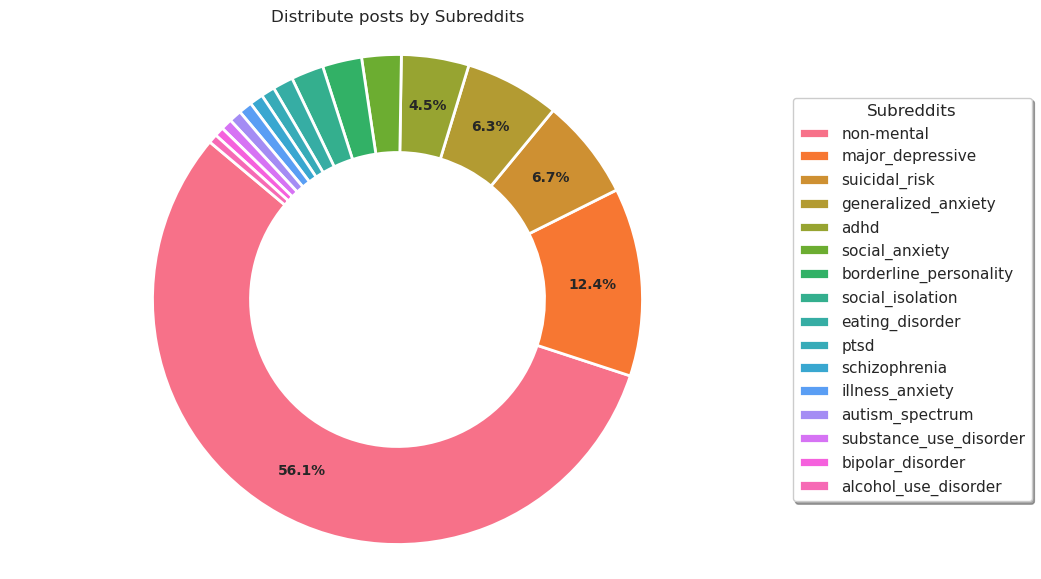

In [10]:
plt.figure(figsize=(10, 7))
wedges, texts, autotexts = plt.pie(
    sub_counts, 
    autopct=lambda pct: (f'{pct:.1f}%') if pct >= 4 else '', 
    startangle=140, 
    colors=sns.color_palette("husl", 16),
    pctdistance=0.8,
    wedgeprops={'width': 0.4, 'edgecolor': '#ffffff', 'linewidth': 2}
)

plt.setp(autotexts, size=10, weight="bold")

plt.legend(
    wedges, 
    sub_counts.index,
    title="Subreddits",
    loc="center left",
    bbox_to_anchor=(1, 0, 0.5, 1),
    shadow=True
)

plt.axis('equal')
plt.title("Distribute posts by Subreddits")
plt.show()

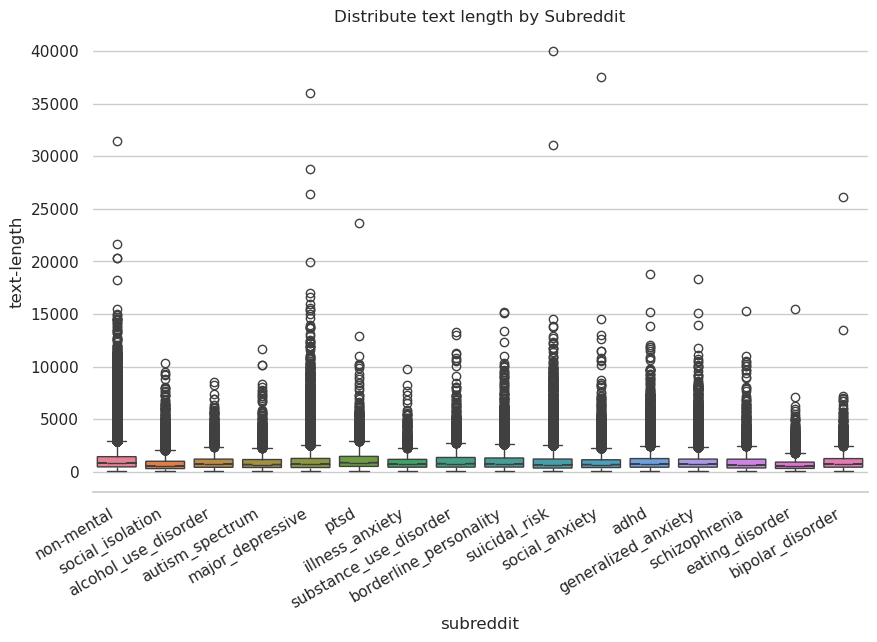

In [11]:
df['text-length'] = df['post'].astype(str).apply(len)

plt.figure(figsize=(10, 6))
sns.boxplot(
    data=df,
    x="subreddit",
    y="text-length",
    notch=True,
    palette=sns.color_palette("husl", 16),
    legend=False,
    hue="subreddit"
)

sns.despine(left=True)
plt.xticks(rotation=30, ha='right')
plt.title("Distribute text length by Subreddit")
plt.show()

In [12]:
def get_wordcloud(textl: list[str], title: str, axes):
    text = " ".join(textl)
    wordcloud = WordCloud(
        width=500,
        height=250,
        colormap="plasma",
        background_color="white",
        random_state=123,
    ).generate(text)

    axes.imshow(wordcloud, interpolation="bilinear")
    axes.axis("off")
    axes.set_title(title, fontsize=20, pad=16)

In [ ]:
labels = df["subreddit"].value_counts().index.tolist()
w, h = 6, 3
fig, axes = plt.subplots(w, h, figsize=(8 * h, 5 * w))
ix = 0

for i in range(w):
    for j in range(h):
        if ix >= len(labels):
            break

        word_list = []

        for senc in df[df["subreddit"] == labels[ix]]["post_clean"]:
            if isinstance(senc, list):
                merged = " ".join(senc)
            else:
                merged = senc
            word_list.append(merged)

        get_wordcloud(word_list, labels[ix], axes=axes[i][j])
        ix += 1

plt.tight_layout(pad=2)
plt.show()